# xCounter — Predição de Sucesso em Contra-Ataques com Prior Físico do Football Manager 2023

**Disciplina:** COE609 - Ciência de Dados Aplicada ao Futebol (UFRJ, 2026.1)

## Objetivo

Construir um modelo preditivo de sucesso de contra-ataques (**xCounter**) substituindo
features físicas de tracking contínuo por um *prior* estático de atributos por jogador
extraído do **Football Manager 2023**.

**Hipótese central:** essa substituição preserva poder preditivo significativo, viabilizando
a metodologia em contextos sem dados de tracking contínuo.

## Pipeline

| Etapa | Descrição |
|-------||-----------|
| 1 | Carregamento dos dados (eventos + StatsBomb 360) |
| 2 | Identificação de cadeias de contra-ataque |
| 3 | Extração de features espaciais via Freeze Frame 360 |
| 4 | Integração com atributos físicos do FM2023 |
| 5 | Escalonamento para as 64 partidas da Copa do Mundo FIFA 2022 |
| 6 | Modelagem comparativa: Baseline Espacial vs. Espacial + Físico |


In [77]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os

from mplsoccer import Sbopen, Pitch
from unidecode import unidecode

print("Bibliotecas carregadas com sucesso.")
import mplsoccer
print(f"  pandas {pd.__version__} | numpy {np.__version__} | mplsoccer {mplsoccer.__version__}")

Bibliotecas carregadas com sucesso.
  pandas 2.2.3 | numpy 2.1.3 | mplsoccer 1.6.1


## 1. Parâmetros e Configuração

Todos os critérios operacionais estão centralizados no bloco `config` para facilitar ajustes e reprodutibilidade.


In [90]:
# ==================
# PARÂMETROS GLOBAIS
# ==================
MATCH_ID       = 3857273   # Copa do Mundo 2022: País de Gales × Irã
COMPETITION_ID = 43        # FIFA World Cup
SEASON_ID      = 106       # 2022

GOAL_X = 120.0  # Coordenada x do gol adversário (sistema StatsBomb: 0-120)
GOAL_Y = 40.0   # Coordenada y do centro do gol

# Atributos físicos do FM2023 a incorporar
FM_ATTRS    = ['Pac', 'Acc', 'Sta', 'Str', 'Agi', 'Bal', 'Jum']
FM_CSV_PATH = 'fm2023_copa_2022.csv'

# ============================================================
# BLOCO DE CONFIGURAÇÃO — xCounter
# Altere apenas aqui para análise de sensibilidade.
# Não toque no corpo das funções.
# ============================================================
config = {
    # --- Zona de início válida para a recuperação ---
    # Opções: "metade_defensiva" (x < 60), "terco_defensivo" (x < 40),
    #         "campo_todo" (qualquer x), "custom" (x < zona_recuperacao_x_max)
    # Sistema de coordenadas StatsBomb: eixo x de 0 a 120; equipe que
    # recupera ataca em direção a x=120.
    "zona_recuperacao":       "metade_defensiva",
    "zona_recuperacao_x_max": None,  # usado só se zona_recuperacao == "custom"

    # --- Janela de análise pós-recuperação ---
    "max_eventos_apos":          20,   # eventos a olhar após a recuperação (5→original)
    "max_tempo_s":               60,  # duração máxima da cadeia em segundos
    "progressao_vertical_min_m": 30,  # ganho mínimo em x (metros) para qualificar

    # --- Condições de quebra da cadeia (avaliadas nesta ordem) ---
    # 1. fim_periodo: period do próx. evento != period do início da cadeia
    # 2. perda_posse: equipe do próx. evento != equipe recuperadora
    # 3. max_tempo_s / max_eventos_apos: sempre verificados (não são flags)
    # 4. falta: próx. evento é Foul Won ou Foul Committed (depois de adicionar)
    # 5. chute: próx. evento é Shot (depois de adicionar)
    "quebrar_em_fim_periodo":  False,  # False → comportamento original
    "quebrar_em_perda_posse":  True,
    "quebrar_em_falta":        False,  # False → comportamento original
    "quebrar_em_chute":        True,

    # --- Eventos que iniciam um contra-ataque ---
    "eventos_inicio": ["Ball Recovery", "Interception", "Duel"],

    # --- Critério de sucesso ---
    # "qualquer_chute" : sucesso se a cadeia termina em qualquer Shot
    # "xg_threshold"   : sucesso se Shot com shot_statsbomb_xg >= xg_threshold
    # "gol"            : sucesso somente se o Shot resultou em gol
    "criterio_sucesso": "qualquer_chute",
    "xg_threshold":     0.10,
}


def validar_config(cfg):
    """Valida parâmetros do config; levanta ValueError com mensagem clara."""
    zonas_validas = {"metade_defensiva", "terco_defensivo", "campo_todo", "custom"}
    if cfg["zona_recuperacao"] not in zonas_validas:
        raise ValueError(f"zona_recuperacao deve ser uma de {zonas_validas}.")
    if cfg["zona_recuperacao"] == "custom" and cfg.get("zona_recuperacao_x_max") is None:
        raise ValueError("zona_recuperacao='custom' requer zona_recuperacao_x_max != None.")
    criterios_validos = {"qualquer_chute", "xg_threshold", "gol"}
    if cfg["criterio_sucesso"] not in criterios_validos:
        raise ValueError(f"criterio_sucesso deve ser um de {criterios_validos}.")
    if cfg["criterio_sucesso"] == "xg_threshold" and cfg.get("xg_threshold") is None:
        raise ValueError("criterio_sucesso='xg_threshold' requer xg_threshold definido.")


validar_config(config)

# Aliases para compatibilidade com as células de visualização
XG_THRESHOLD             = config["xg_threshold"]
CRIT_TEMPO_MAX_S         = config["max_tempo_s"]
CRIT_DIST_VERTICAL_MIN_M = config["progressao_vertical_min_m"]
CRIT_MAX_EVENTOS         = config["max_eventos_apos"]

print("Parâmetros configurados e validados.")
print(f"  Match ID: {MATCH_ID} | Zona: {config['zona_recuperacao']} | "
      f"xG threshold: {XG_THRESHOLD}")
print(f"  Tempo máx: {CRIT_TEMPO_MAX_S}s | Progressão mín: "
      f"{CRIT_DIST_VERTICAL_MIN_M}m | Eventos máx pós-rec.: {CRIT_MAX_EVENTOS}")


Parâmetros configurados e validados.
  Match ID: 3857273 | Zona: metade_defensiva | xG threshold: 0.1
  Tempo máx: 60s | Progressão mín: 30m | Eventos máx pós-rec.: 20


## 2. Etapa 1 — Carregamento de Dados

Inicializa o parser StatsBomb (`Sbopen`) e carrega os dados de referência. O objeto `parser` é global e reutilizado por `processar_partida` e `rodar_analise_sensibilidade` ao longo do pipeline.

- `parser.event(match_id)` → 4 DataFrames: eventos, relacionados, freeze de chutes, táticas
- `parser.frame(match_id)` → 2 DataFrames: `df_360` (posições por evento) e `df_visible` (área rastreada)
- `parser.match(competition_id, season_id)` → metadados de todas as partidas da competição

O `df_360` tem colunas `[teammate, actor, keeper, match_id, id, x, y]` — uma linha por jogador visível em cada evento com cobertura 360.


In [79]:
print("=== Etapa 1: Carregamento dos Dados ===\n")
parser = Sbopen()

# Eventos e táticas
df_event, df_related, df_freeze_shots, df_tactics = parser.event(MATCH_ID)

# Freeze frames 360 de todos os eventos com cobertura
df_360, df_visible = parser.frame(MATCH_ID)

# Metadados da partida
df_match_info = parser.match(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_row     = df_match_info[df_match_info['match_id'] == MATCH_ID].iloc[0]

home_team  = match_row['home_team_name']
away_team  = match_row['away_team_name']
home_score = int(match_row['home_score'])
away_score = int(match_row['away_score'])

print(f"Partida:  {home_team}  {home_score} x {away_score}  {away_team}")
print(f"Data:     {str(match_row['match_date'])[:10]}")
print(f"\nEventos carregados:          {len(df_event):,}")
print(f"Linhas no DataFrame 360:     {len(df_360):,}")
print(f"Eventos com frame 360:       {df_360['id'].nunique():,}")
print(f"\nTipos de evento mais comuns:")
print(df_event['type_name'].value_counts().head(20).to_string())

=== Etapa 1: Carregamento dos Dados ===

Partida:  Wales  0 x 2  Iran
Data:     2022-11-25

Eventos carregados:          3,133
Linhas no DataFrame 360:     42,319
Eventos com frame 360:       2,768

Tipos de evento mais comuns:
type_name
Pass               922
Ball Receipt       760
Carry              645
Pressure           251
Ball Recovery      120
Duel                70
Clearance           51
Block               46
Goal Keeper         38
Shot                31
Miscontrol          28
Dribble             27
Interception        25
Foul Committed      19
Foul Won            19
Dispossessed        16
Dribbled Past       13
Injury Stoppage     10
Substitution         9
50/50                8


## 3. Etapa 2 — Identificação de Contra-Ataques

Uma cadeia é classificada como **contra-ataque** se atende simultaneamente a:

| Critério | Parâmetro |
|----------||-----------|
| Início: Ball Recovery, Interception ou Duel vencido | `zona_recuperacao = "metade_defensiva"` (x < 60) |
| Duração máxima | `max_tempo_s = 15s` |
| Progressão mínima no eixo x | `progressao_vertical_min_m = 30m` |
| Nº máximo de eventos pós-recuperação | `max_eventos_apos = 10` |

**Rótulo binário:**
- `sucesso = 1` → cadeia termina em chute com `shot_statsbomb_xg ≥ xg_threshold`
- `sucesso = 0` → caso contrário (inclui cadeias sem finalização)

A função `rodar_analise_sensibilidade` (definida a seguir) permite comparar o impacto de diferentes parametrizações — ver Apêndice para demonstração.


In [ ]:
# ============================================================
# ETAPA 2: IDENTIFICAÇÃO DE CONTRA-ATAQUES
# ============================================================

# Eventos do adversário que NÃO contam como perda de posse efetiva.
# Aparecem como team_name diferente no df_event, mas a posse 'lógica'
# permanece com a equipe atacante (ex.: Pressure interrompe a cadeia
# antes do chute, deflacionando terminou_chute = True).
EVENTOS_DEFENSIVOS_NEUTROS = {
    "Pressure",
    "Block",
    "Clearance",
    "50/50",
    "Shield",
    "Error",
}

def _resolver_x_max_zona(cfg):
    """Traduz zona_recuperacao para o limite numérico em x."""
    zona = cfg["zona_recuperacao"]
    if zona == "metade_defensiva":
        return 60.0
    if zona == "terco_defensivo":
        return 40.0
    if zona == "campo_todo":
        return float("inf")
    return float(cfg["zona_recuperacao_x_max"])  # custom


def identificar_contra_ataques(df_event, cfg):
    """
    Identifica cadeias de contra-ataque a partir do dataframe de eventos.
    Recebe `cfg` (dict de config) com todos os critérios operacionais.

    Ordem de avaliação das condições de quebra do loop interno:
      ANTES de adicionar o evento à cadeia:
        1. quebrar_em_fim_periodo  — period diferente do início
        2. quebrar_em_perda_posse  — equipe diferente da recuperadora
        3. max_tempo_s             — sempre verificado
      APÓS adicionar o evento à cadeia:
        4. quebrar_em_falta        — Foul Won / Foul Committed
        5. quebrar_em_chute        — Shot

    Retorna lista de dicts com metadados de cada cadeia qualificada.
    """
    x_max_zona       = _resolver_x_max_zona(cfg)
    max_eventos      = cfg["max_eventos_apos"]
    max_tempo        = cfg["max_tempo_s"]
    prog_min         = cfg["progressao_vertical_min_m"]
    eventos_inicio   = set(cfg["eventos_inicio"])
    criterio_sucesso = cfg["criterio_sucesso"]
    xg_thr           = cfg.get("xg_threshold", 0.10)

    contra_ataques = []
    df = df_event.sort_values(["period", "minute", "second", "index"]).reset_index(drop=True)

    i = 0
    while i < len(df):
        ev    = df.iloc[i]
        x_ev  = ev.get("x")
        if pd.isna(x_ev):
            i += 1
            continue

        eh_rec  = ev["type_name"] in eventos_inicio
        na_zona = float(x_ev) < x_max_zona

        # Duels: apenas se foram vencidos
        if ev["type_name"] == "Duel":
            outcome = str(ev.get("outcome_name", "")).lower()
            eh_rec  = "won" in outcome

        if eh_rec and na_zona:
            t0        = ev["minute"] * 60 + ev["second"]
            equipe    = ev["team_name"]
            period_ev = ev["period"]
            cadeia    = [ev]

            j = i + 1
            while j < len(df) and len(cadeia) <= max_eventos:
                prox = df.iloc[j]
                t    = prox["minute"] * 60 + prox["second"]

                # Condições de quebra ANTES de adicionar (ordem 1 → 3)
                if cfg["quebrar_em_fim_periodo"] and prox["period"] != period_ev:
                    break
                if cfg["quebrar_em_perda_posse"]:
                    mudou_equipe = prox["team_name"] != equipe
                    eh_defensivo_neutro = prox["type_name"] in EVENTOS_DEFENSIVOS_NEUTROS
                    if mudou_equipe and not eh_defensivo_neutro:
                        break
                if (t - t0) > max_tempo:
                    break

                cadeia.append(prox)
                j += 1

                # Condições de quebra APÓS adicionar (ordem 4 → 5)
                if cfg["quebrar_em_falta"] and prox["type_name"] in {"Foul Won", "Foul Committed"}:
                    break
                if cfg["quebrar_em_chute"] and prox["type_name"] == "Shot":
                    break

            # Calcular métricas da cadeia
            x_ini   = float(ev["x"])
            ultimo  = cadeia[-1]
            x_fim   = ultimo.get("end_x")
            if pd.isna(x_fim):
                x_fim = ultimo.get("x", x_ini)
            x_fim   = float(x_fim) if not pd.isna(x_fim) else x_ini

            prog           = x_fim - x_ini
            terminou_chute = (ultimo["type_name"] == "Shot")
            xg_final       = float(ultimo.get("shot_statsbomb_xg") or 0) if terminou_chute else 0.0
            t_final        = ultimo["minute"] * 60 + ultimo["second"]
            duracao_s      = float(t_final - t0)

            # Critério de sucesso
            if criterio_sucesso == "qualquer_chute":
                sucesso = terminou_chute
            elif criterio_sucesso == "gol":
                sucesso = terminou_chute and str(ultimo.get("outcome_name", "")).lower() == "goal"
            else:  # xg_threshold
                sucesso = bool(terminou_chute and xg_final >= xg_thr)

            if prog >= prog_min:
                contra_ataques.append({
                    "id_inicio":      cadeia[0]["id"],
                    "player_id":      cadeia[0].get("player_id"),
                    "player_name":    str(cadeia[0].get("player_name", "")),
                    "team":           equipe,
                    "period":         int(cadeia[0]["period"]),
                    "minute":         int(cadeia[0]["minute"]),
                    "second":         int(cadeia[0]["second"]),
                    "tipo_inicio":    cadeia[0]["type_name"],
                    "x_inicio":       x_ini,
                    "y_inicio":       float(cadeia[0].get("y") or 40.0),
                    "num_eventos":    len(cadeia),
                    "progressao_x":   float(prog),
                    "duracao_s":      duracao_s,
                    "terminou_chute": terminou_chute,
                    "xg_final":       xg_final,
                    "sucesso":        bool(sucesso),
                })
        i += 1

    return contra_ataques


print("Funções _resolver_x_max_zona e identificar_contra_ataques definidas.")


Funções _resolver_x_max_zona e identificar_contra_ataques definidas.


In [81]:
# ============================================================
# FUNÇÃO: rodar_analise_sensibilidade
# ============================================================

def rodar_analise_sensibilidade(lista_configs, match_ids):
    """
    Roda identificar_contra_ataques para várias configs e várias partidas.

    Parâmetros
    ----------
    lista_configs : list[dict]  — configs a comparar (cada uma validada internamente)
    match_ids     : list[int]   — IDs das partidas a analisar

    Retorna
    -------
    pd.DataFrame com uma linha por config:
        config_idx, zona_recuperacao, max_eventos, max_tempo_s, prog_min_m,
        criterio_sucesso, n_contra_ataques, n_sucessos, taxa_sucesso, duracao_media_s
    """
    resultados = []
    for idx_cfg, cfg in enumerate(lista_configs):
        validar_config(cfg)
        n_ca, n_suc = 0, 0
        duracoes = []

        for mid in match_ids:
            df_ev, _, _, _ = parser.event(mid)
            cas = identificar_contra_ataques(df_ev, cfg)
            n_ca  += len(cas)
            n_suc += sum(c["sucesso"] for c in cas)
            duracoes.extend(c["duracao_s"] for c in cas)

        taxa      = n_suc / n_ca if n_ca > 0 else float("nan")
        dur_media = sum(duracoes) / len(duracoes) if duracoes else float("nan")

        resultados.append({
            "config_idx":       idx_cfg,
            "zona_recuperacao":  cfg["zona_recuperacao"],
            "max_eventos":       cfg["max_eventos_apos"],
            "max_tempo_s":       cfg["max_tempo_s"],
            "prog_min_m":        cfg["progressao_vertical_min_m"],
            "criterio_sucesso":  cfg["criterio_sucesso"],
            "n_contra_ataques":  n_ca,
            "n_sucessos":        n_suc,
            "taxa_sucesso":      round(taxa, 4),
            "duracao_media_s":   round(dur_media, 2),
        })

    return pd.DataFrame(resultados)


print("Função rodar_analise_sensibilidade definida.")


Função rodar_analise_sensibilidade definida.


## 4. Etapa 3 — Features Espaciais do Freeze Frame 360

Para cada cadeia de contra-ataque, recupera-se o freeze frame do evento de início e calculam-se 7 features de posicionamento:

| Feature | Cálculo |
|---------||---------|
| `dist_gol_defensor_proximo` | Dist. Euclidiana: gol → defensor mais avançado (maior `x` entre oponentes) |
| `dist_gol_atacante_avancado` | Dist. Euclidiana: gol → atacante mais avançado (maior `x` entre companheiros) |
| `diferencial_profundidade` | `x_atacante_avancado − x_defensor_mais_avancado` |
| `num_defensores_entre_bola_gol` | Oponentes com `x > x_bola` |
| `largura_linha_defensiva` | Spread em `y` dos 3 defensores mais avançados |
| `dist_bola_gol` | Distância Euclidiana da bola ao gol no instante da recuperação |
| `superioridade_terco_ofensivo` | `(companheiros com x > 80) − (oponentes com x > 80)` |


In [82]:
# ============================================================
# ETAPA 3: FEATURES ESPACIAIS DO FREEZE FRAME 360
# ============================================================

def dist_eucl(x, y, x0=GOAL_X, y0=GOAL_Y):
    """Distância Euclidiana de (x, y) ao gol adversário (x=120, y=40)."""
    return float(np.sqrt((x - x0)**2 + (y - y0)**2))


def extrair_features_espaciais(event_id, df_event, df_360):
    """
    Extrai features espaciais do freeze frame 360 de um evento.
    Retorna dict com as 7 features ou None se o frame não estiver disponível.
    """
    ev = df_event[df_event["id"] == event_id]
    if ev.empty:
        return None
    ev = ev.iloc[0]

    frame = df_360[df_360["id"] == event_id]
    if frame.empty:
        return None

    bola_x = ev.get("x")
    bola_y = ev.get("y")
    if bola_x is None or pd.isna(bola_x):
        return None
    bola_x, bola_y = float(bola_x), float(bola_y)

    # teammate=True  → companheiros do recuperador (atacantes no CA)
    # teammate=False → adversários (defensores)
    tm = frame[frame["teammate"] == True].copy()
    op = frame[frame["teammate"] == False].copy()

    if len(op) < 1 or len(tm) < 1:
        return None

    # Defensor mais avançado
    x_def_av = float(op["x"].max())
    y_def_av = float(op.loc[op["x"].idxmax(), "y"])

    # Atacante mais avançado
    x_atac_av = float(tm["x"].max())
    y_atac_av = float(tm.loc[tm["x"].idxmax(), "y"])

    # Defensores entre bola e gol
    n_def_entre = int((op["x"] > bola_x).sum())

    # Largura da linha defensiva (3 mais avançados)
    top3 = op.nlargest(min(3, len(op)), "x")
    largura = float(top3["y"].max() - top3["y"].min()) if len(top3) >= 2 else 0.0

    # Superioridade no terço ofensivo
    sup_of = int((tm["x"] > 80).sum()) - int((op["x"] > 80).sum())

    return {
        "event_id":                      event_id,
        "dist_gol_defensor_proximo":     dist_eucl(x_def_av, y_def_av),
        "dist_gol_atacante_avancado":    dist_eucl(x_atac_av, y_atac_av),
        "diferencial_profundidade":      x_atac_av - x_def_av,
        "num_defensores_entre_bola_gol": n_def_entre,
        "largura_linha_defensiva":       largura,
        "dist_bola_gol":                 dist_eucl(bola_x, bola_y),
        "superioridade_terco_ofensivo":  sup_of,
    }

## 5. Etapa 4 — Integração com Football Manager 2023

> ### Simplificações documentadas
>
> 1. **Atacante:** o `player_name` vem diretamente do evento de início da cadeia (disponível em `df_event`).
>
> 2. **Defensor proxy:** como o freeze frame 360 não contém `player_id`, usa-se o primeiro
>    jogador adversário com posição defensiva (CB, LB, RB) da escalação tática inicial.
>    Esse proxy é fixo para todos os contra-ataques de uma equipe.
>
> 3. **Casamento de nomes:** via unidecode + lowercase + múltiplas estratégias de substring.
>    Nomes compostos StatsBomb (ex.: "Lionel Andrés Messi Cuccittini") são decompostos para encontrar
>    a entrada FM2023 correspondente ("Lionel Messi").

### Atributos físicos incorporados

| Atributo FM | Papel no modelo |
|-------------|----------------|
| `Pac` (Pace) | Velocidade máxima |
| `Acc` (Acceleration) | Aceleração |
| `Sta` (Stamina) | Resistência |
| `Str` (Strength) | Força |
| `Agi` (Agility) | Agilidade |
| `Bal` (Balance) | Equilíbrio |
| `Jum` (Jumping Reach) | Alcance no salto |

O modelo usa **médias dos defensores** (via `get_defender_attrs_medios`) e atributos individuais do atacante (via `buscar_fm`), derivando 6 features físicas finais: `pace_atacante`, `acceleration_atacante`, `pace_defensor`, `acceleration_defensor`, `diferencial_pace`, `diferencial_acceleration`.


In [84]:
# ============================================================
# ETAPA 4A: CARREGAMENTO DO FM2023 + LINEUP
# ============================================================

def norm_nome(nome):
    """Normaliza nome: unidecode + lowercase + remove não-letras + sufixos."""
    nome = unidecode(str(nome)).lower()
    nome = re.sub(r'[^a-z\s]', '', nome)
    nome = re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', nome)
    return re.sub(r'\s+', ' ', nome).strip()


# Mapeamento StatsBomb country_name → código FM2023 (Nat).
# Construído a partir dos 32 country_names únicos presentes nas lineups
# da Copa do Mundo FIFA 2022 (competition_id=43, season_id=106).
# Casos não-óbvios: '\xa0' = non-breaking space no dado fonte (Korea).
COUNTRY_TO_FM = {
    'Argentina':                 'ARG',
    'Australia':                 'AUS',
    'Belgium':                   'BEL',
    'Brazil':                    'BRA',
    'Cameroon':                  'CMR',
    'Canada':                    'CAN',
    'Costa Rica':                'CRC',
    'Croatia':                   'CRO',
    'Denmark':                   'DEN',
    'Ecuador':                   'ECU',
    'England':                   'ENG',
    'France':                    'FRA',
    'Germany':                   'GER',
    'Ghana':                     'GHA',
    'Iran, Islamic Republic of': 'IRN',
    'Japan':                     'JPN',
    'Korea\xa0(South)':          'KOR',
    'Mexico':                    'MEX',
    'Morocco':                   'MAR',
    'Netherlands':               'NED',
    'Poland':                    'POL',
    'Portugal':                  'POR',
    'Qatar':                     'QAT',
    'Saudi Arabia':              'KSA',
    'Senegal':                   'SEN',
    'Serbia':                    'SRB',
    'Spain':                     'ESP',
    'Switzerland':               'SUI',
    'Tunisia':                   'TUN',
    'United States of America':  'USA',
    'Uruguay':                   'URU',
    'Wales':                     'WAL',
}

df_fm = None

if os.path.exists(FM_CSV_PATH):
    print(f"Carregando FM2023: {FM_CSV_PATH}")
    df_fm = pd.read_csv(FM_CSV_PATH, encoding='utf-8')
    df_fm.columns = [c.strip() for c in df_fm.columns]
    for col in df_fm.select_dtypes('object').columns:
        df_fm[col] = df_fm[col].astype(str).str.strip()
    for attr in FM_ATTRS:
        df_fm[attr] = pd.to_numeric(df_fm[attr], errors='coerce')
    df_fm['name_norm'] = df_fm['Name'].apply(norm_nome)

    # Parsear DoB: "DD/M/YYYY (N years old)" → "YYYY-MM-DD"
    def _parse_dob(dob_str):
        m = re.match(r'(\d{1,2})/(\d{1,2})/(\d{4})', str(dob_str))
        return f"{m.group(3)}-{int(m.group(2)):02d}-{int(m.group(1)):02d}" if m else None
    df_fm['DoB_parsed'] = df_fm['DoB'].apply(_parse_dob)

    n_dob = df_fm['DoB_parsed'].notna().sum()
    print(f"  Jogadores carregados : {len(df_fm):,}")
    print(f"  DoB_parsed preenchido: {n_dob:,} / {len(df_fm):,}")
    for q in ['lionel messi', 'kylian mbappe', 'cristiano ronaldo']:
        r = df_fm[df_fm['name_norm'].str.contains(q, na=False)]
        if len(r) > 0:
            row = r.iloc[0]
            print(f"  Verificação — {q}: Pac={row['Pac']}, DoB_parsed={row['DoB_parsed']}")

# --- Lineup: player_id → código FM de nacionalidade ---
print(f"\nCarregando lineup da partida {MATCH_ID}...")
df_lineup = parser.lineup(MATCH_ID)

nat_fm_por_player = (
    df_lineup
    .assign(nat_fm=df_lineup['country_name'].map(COUNTRY_TO_FM))
    .set_index('player_id')['nat_fm']
    .to_dict()
)

n_mapeados = sum(1 for v in nat_fm_por_player.values() if pd.notna(v))
print(f"  Jogadores no lineup      : {len(df_lineup)}")
print(f"  Nac. mapeadas para FM    : {n_mapeados} / {len(nat_fm_por_player)}")

paises_nao_mapeados = (df_lineup[~df_lineup['country_name'].isin(COUNTRY_TO_FM)]
                       ['country_name'].dropna().unique())
if len(paises_nao_mapeados):
    print(f"  AVISO — country_names sem mapeamento: {paises_nao_mapeados.tolist()}")

Carregando FM2023: fm2023_copa_2022.csv
  Jogadores carregados : 819
  DoB_parsed preenchido: 819 / 819
  Verificação — lionel messi: Pac=15, DoB_parsed=1987-06-24
  Verificação — kylian mbappe: Pac=20, DoB_parsed=1998-12-20
  Verificação — cristiano ronaldo: Pac=13, DoB_parsed=1985-02-05

Carregando lineup da partida 3857273...
  Jogadores no lineup      : 51
  Nac. mapeadas para FM    : 51 / 51


In [85]:
# ============================================================
# ETAPA 4B: ATRIBUTOS MEDIOS DOS DEFENSORES (via FM2023)
# ============================================================
# StatsBomb usa grafia americana (Center) -- inclui ambas as formas.
POSICOES_DEFENSIVAS = [
    'Centre Back',       'Center Back',
    'Left Back',         'Right Back',
    'Left Centre Back',  'Left Center Back',
    'Right Centre Back', 'Right Center Back',
    'Left Wing Back',    'Right Wing Back',
    'Sweeper',
]


def get_defender_attrs_medios(df_event, df_tactics):
    xi_ev = (df_event[df_event['type_name'] == 'Starting XI']
             [['id', 'team_name']].drop_duplicates())
    tact  = df_tactics.merge(xi_ev, on='id', how='inner')

    resultado = {}
    for team, grp in tact.groupby('team_name'):
        def_pl = grp[grp['position_name'].isin(POSICOES_DEFENSIVAS)]
        if len(def_pl) == 0:
            def_pl = grp[grp['position_name'] != 'Goalkeeper']
        if len(def_pl) == 0:
            def_pl = grp

        attrs_list, nomes_ok, nomes_nao = [], [], []
        for _, p in def_pl.iterrows():
            nat = nat_fm_por_player.get(p['player_id'])
            at, found, strat = buscar_fm(p['player_name'], nationality=nat)
            if at is not None:
                attrs_list.append(at)
                nomes_ok.append(f"{p['player_name']} -> {found} [{strat}]")
            else:
                nomes_nao.append(p['player_name'])

        if attrs_list:
            df_def = pd.DataFrame(attrs_list)
            medias = {attr: float(df_def[attr].mean()) for attr in FM_ATTRS}
        else:
            medias = {attr: np.nan for attr in FM_ATTRS}

        medias['_nomes_ok']      = nomes_ok
        medias['_nomes_nao']     = nomes_nao
        medias['_n_defensores']  = len(def_pl)
        medias['_n_encontrados'] = len(attrs_list)
        resultado[team] = medias

    return resultado


print('Funcao get_defender_attrs_medios definida.')
print('  (chamada em Etapa 4D, apos buscar_fm estar disponivel)')


Funcao get_defender_attrs_medios definida.
  (chamada em Etapa 4D, apos buscar_fm estar disponivel)


In [86]:
# ============================================================
# ETAPA 4C: FUNÇÃO DE BUSCA NO FM2023
# ============================================================

def buscar_fm(player_name, birth_date=None, nationality=None, tolerancia_dias=2):
    """
    Busca atributos físicos no FM2023 com filtros em cascata.

    Filtros de pool (do mais específico ao mais amplo):
      1. nationality + birth_date  — nunca ativado automaticamente
         (StatsBomb open data não expõe DoB dos jogadores)
      2. nationality only          — ativado sempre que disponível
      3. birth_date only           — idem
      4. Sem filtro (full DB)      — fallback final

    Para cada pool, tenta as estratégias de nome em ordem decrescente
    de especificidade. Múltiplos matches → prefere o de maior Pac.

    Retorna (dict_atributos, nome_encontrado, estrategia)
         ou (None, player_name, "não_encontrado").
    """
    palavras = norm_nome(player_name).split()
    if not palavras:
        return None, player_name, "vazio"

    # Candidatos de busca, do mais para o menos específico
    candidatos = [norm_nome(player_name)]
    for n in range(len(palavras) - 1, 1, -1):
        for s in range(len(palavras) - n + 1):
            candidatos.append(' '.join(palavras[s:s+n]))
    for i in range(1, len(palavras)):
        candidatos.append(f'{palavras[0]} {palavras[i]}')
    if len(palavras) >= 3:
        candidatos.append(f'{palavras[-2]} {palavras[-1]}')
    candidatos = list(dict.fromkeys(candidatos))  # preserva ordem, remove dups

    def _buscar_em(pool):
        for q in candidatos:
            if len(q) < 7:
                continue
            r = pool[pool['name_norm'] == q]
            if len(r) >= 1:
                row = r.loc[r['Pac'].fillna(0).idxmax()]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'exato:{q}'
            r = pool[pool['name_norm'].str.contains(re.escape(q), na=False)]
            if len(r) == 1:
                row = r.iloc[0]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'contains:{q}'
        # Última chance: palavra única longa e exclusiva no pool
        for p in sorted(set(palavras), key=len, reverse=True):
            if len(p) < 6:
                continue
            r = pool[pool['name_norm'].str.contains(r'\b' + re.escape(p) + r'\b',
                                                    na=False, regex=True)]
            if len(r) == 1:
                row = r.iloc[0]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'palavra:{p}'
        return None, player_name, "não_encontrado"

    # Montar filtros de pool em cascata
    filtros = []
    if birth_date is not None and nationality is not None:
        filtros.append(('dob+nat', df_fm[
            (df_fm['Nat'] == nationality) & (df_fm['DoB_parsed'] == birth_date)
        ]))
    if nationality is not None:
        filtros.append(('nat', df_fm[df_fm['Nat'] == nationality]))
    if birth_date is not None:
        filtros.append(('dob', df_fm[df_fm['DoB_parsed'] == birth_date]))
    filtros.append(('full', df_fm))  # fallback sem filtro

    for filtro_nome, pool in filtros:
        if len(pool) == 0:
            continue
        attrs, found, strat = _buscar_em(pool)
        if attrs is not None:
            return attrs, found, f'{filtro_nome}+{strat}'

    return None, player_name, "não_encontrado"


print("Função buscar_fm() definida.")
print("  Filtros em cascata: dob+nat → nat → dob → full")

Função buscar_fm() definida.
  Filtros em cascata: dob+nat → nat → dob → full


## 6. Etapa 5 — Escalonamento para 64 Partidas

`processar_partida` encapsula as Etapas 1–4 numa função reutilizável. O loop aplica a função sobre todas as partidas da Copa do Mundo FIFA 2022 e consolida os resultados num único dataset.


In [87]:
# =======================================================
# ETAPA 5A — Função processar_partida
# =======================================================
# df_fm e parser permanecem globais (carregados nas Etapas 1 e 4A).
# buscar_fm acessa df_fm como global — contrato mantido para não regredir células existentes.

def processar_partida(match_id, config):
    # 1. Carregamento
    df_ev, _, _, df_tac = parser.event(match_id)
    df_fr, _            = parser.frame(match_id)
    df_ln               = parser.lineup(match_id)

    # Mapeamento player_id → nacionalidade FM (NaN para países fora do COUNTRY_TO_FM)
    nat_map = (
        df_ln
        .assign(nat_fm=df_ln['country_name'].map(COUNTRY_TO_FM))
        .set_index('player_id')['nat_fm']
        .to_dict()
    )

    # Log de países sem mapeamento FM (uma vez por partida, não por jogador)
    paises_nao_mapeados = (
        df_ln[df_ln['country_name'].map(COUNTRY_TO_FM).isna()]['country_name']
        .dropna().unique().tolist()
    )
    if paises_nao_mapeados:
        print(f"    [AVISO] match={match_id}: países sem mapeamento FM → {paises_nao_mapeados}")

    # 2. Identificar contra-ataques
    cas = identificar_contra_ataques(df_ev, config)
    if not cas:
        return pd.DataFrame(), 0, 0

    n_ca_total = len(cas)

    # 3. Features espaciais
    feat_rows, n_sem_frame = [], 0
    for ca in cas:
        feats = extrair_features_espaciais(ca["id_inicio"], df_ev, df_fr)
        if feats is not None:
            feat_rows.append(feats)
        else:
            n_sem_frame += 1

    if not feat_rows:
        return pd.DataFrame(), n_ca_total, n_sem_frame

    df_feats   = pd.DataFrame(feat_rows)
    df_dataset = (
        pd.DataFrame(cas)
        .merge(df_feats.rename(columns={"event_id": "id_inicio"}),
               on="id_inicio", how="inner")
    )

    # 4. Atributos FM — lógica idêntica à Etapa 4D
    defender_attrs = get_defender_attrs_medios(df_ev, df_tac)
    equipes_lista  = list(defender_attrs.keys())

    fm_rows = []
    for _, ca in df_dataset.iterrows():
        equipe_atac = ca['team']
        equipe_def  = next((e for e in equipes_lista if e != equipe_atac), equipe_atac)

        atac_name = ca.get('player_name', '')
        atac_pid  = ca.get('player_id')
        nat_raw   = nat_map.get(atac_pid) if pd.notna(atac_pid or np.nan) else None
        # map() retorna NaN para países não mapeados; garantir string ou None para buscar_fm
        atac_nat  = nat_raw if isinstance(nat_raw, str) else None

        atac_attrs, atac_found, atac_strat = buscar_fm(atac_name, nationality=atac_nat)
        if atac_attrs is None:
            atac_attrs = {a: np.nan for a in FM_ATTRS}

        def_info = defender_attrs.get(equipe_def, {})
        pac_atac = atac_attrs.get('Pac', np.nan)
        acc_atac = atac_attrs.get('Acc', np.nan)
        pac_def  = def_info.get('Pac', np.nan)
        acc_def  = def_info.get('Acc', np.nan)

        fm_rows.append({
            "id_inicio":                ca["id_inicio"],
            "atac_fm_nome":             atac_found,
            "atac_fm_estrategia":       atac_strat,
            "pace_atacante":            pac_atac,
            "acceleration_atacante":    acc_atac,
            "stamina_atacante":         atac_attrs.get('Sta', np.nan),
            "pace_defensor":            pac_def,
            "acceleration_defensor":    acc_def,
            "diferencial_pace":         (pac_atac - pac_def)
                                        if not (pd.isna(pac_atac) or pd.isna(pac_def)) else np.nan,
            "diferencial_acceleration": (acc_atac - acc_def)
                                        if not (pd.isna(acc_atac) or pd.isna(acc_def)) else np.nan,
        })

    df_fm_feats = pd.DataFrame(fm_rows)
    df_result   = df_dataset.merge(df_fm_feats, on="id_inicio", how="left")
    df_result["match_id"] = match_id
    return df_result, n_ca_total, n_sem_frame

print("Função processar_partida definida.")

Função processar_partida definida.


In [91]:
# =======================================================
# ETAPA 5C — Loop sobre as 64 partidas
# =======================================================
df_match_all = parser.match(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_ids    = df_match_all['match_id'].tolist()
print(f"Total de partidas: {len(match_ids)}")

todos_dfs = []
falhas    = []
auditoria = []

for i, mid in enumerate(match_ids, 1):
    row_info = df_match_all[df_match_all['match_id'] == mid].iloc[0]
    label    = f"{row_info['home_team_name']} x {row_info['away_team_name']}"
    print(f"[{i:2d}/{len(match_ids)}] {label} (id={mid}) ...", end=" ", flush=True)

    try:
        df_p, n_ca, n_sf = processar_partida(mid, config)
        n_rows = len(df_p)
        if n_rows > 0:
            todos_dfs.append(df_p)
        auditoria.append({"match_id": mid, "partida": label,
                          "n_ca_total": n_ca, "n_sem_frame": n_sf,
                          "n_no_dataset": n_rows, "erro": None})
        print(f"OK — {n_ca} CAs, {n_sf} sem frame, {n_rows} no dataset")
    except Exception as exc:
        falhas.append((mid, label, str(exc)))
        auditoria.append({"match_id": mid, "partida": label,
                          "n_ca_total": 0, "n_sem_frame": 0,
                          "n_no_dataset": 0, "erro": str(exc)})
        print(f"ERRO: {exc}")

df_dataset_completo = pd.concat(todos_dfs, ignore_index=True) if todos_dfs else pd.DataFrame()
print(f"\nProcessamento concluído.")
print(f"  Partidas OK: {len(match_ids) - len(falhas)}/{len(match_ids)}")
if falhas:
    print(f"  Falhas ({len(falhas)}):")
    for mid, lbl, err in falhas:
        print(f"    id={mid} ({lbl}): {err}")

Total de partidas: 64
[ 1/64] Canada x Morocco (id=3857276) ... OK — 35 CAs, 6 sem frame, 29 no dataset
[ 2/64] England x Iran (id=3857271) ... OK — 23 CAs, 3 sem frame, 20 no dataset
[ 3/64] Croatia x Belgium (id=3857296) ... OK — 33 CAs, 5 sem frame, 28 no dataset
[ 4/64] Netherlands x Ecuador (id=3857274) ... OK — 29 CAs, 3 sem frame, 26 no dataset
[ 5/64] Japan x Spain (id=3857255) ... OK — 22 CAs, 0 sem frame, 22 no dataset
[ 6/64] England x United States (id=3857272) ... OK — 32 CAs, 5 sem frame, 27 no dataset
[ 7/64] Iran x United States (id=3857278) ... OK — 42 CAs, 5 sem frame, 37 no dataset
[ 8/64] Morocco x Croatia (id=3857277) ... OK — 36 CAs, 2 sem frame, 34 no dataset
[ 9/64] Wales x Iran (id=3857273) ... OK — 46 CAs, 3 sem frame, 43 no dataset
[10/64] Tunisia x France (id=3857275) ... OK — 33 CAs, 3 sem frame, 30 no dataset
[11/64] Wales x England (id=3857261) ... OK — 15 CAs, 4 sem frame, 11 no dataset
[12/64] Switzerland x Cameroon (id=3857290) ... OK — 30 CAs, 3 sem f

In [92]:
# =======================================================
# ETAPA 5D — Salvar e resumo descritivo
# =======================================================
PARQUET_PATH = "dataset_completo.parquet"
df_dataset_completo.to_parquet(PARQUET_PATH, index=False)
print(f"Dataset salvo em: {PARQUET_PATH}")

df_aud = pd.DataFrame(auditoria)
n_ok   = df_aud['erro'].isna().sum()
n_fail = df_aud['erro'].notna().sum()

print(f"\n{'='*60}")
print("RESUMO DO DATASET CONSOLIDADO")
print(f"{'='*60}")
print(f"Partidas: {n_ok} OK, {n_fail} com erro")
print(f"Contra-ataques identificados (total): {df_aud['n_ca_total'].sum()}")
print(f"  Com freeze frame 360 (no dataset)  : {len(df_dataset_completo)}")
print(f"  Sem freeze frame 360 (descartados) : {df_aud['n_sem_frame'].sum()}")

if len(df_dataset_completo) > 0:
    suc = df_dataset_completo['sucesso']
    print(f"\nAlvo 'sucesso':")
    print(f"  Positivos (1): {suc.sum():4d}  ({suc.mean():.1%})")
    print(f"  Negativos (0): {(~suc).sum():4d}  ({(~suc).mean():.1%})")

    features_all = [
        'dist_gol_defensor_proximo', 'dist_gol_atacante_avancado',
        'diferencial_profundidade', 'num_defensores_entre_bola_gol',
        'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo',
        'pace_atacante', 'acceleration_atacante', 'pace_defensor',
        'acceleration_defensor', 'diferencial_pace', 'diferencial_acceleration',
    ]
    cols_ok = [c for c in features_all if c in df_dataset_completo.columns]
    print(f"\nEstatísticas das features:")
    print(df_dataset_completo[cols_ok].describe().round(2).to_string())

    print(f"\nDistribuição por equipe (top 10):")
    print(df_dataset_completo['team'].value_counts().head(10).to_string())

Dataset salvo em: dataset_completo.parquet

RESUMO DO DATASET CONSOLIDADO
Partidas: 64 OK, 0 com erro
Contra-ataques identificados (total): 1990
  Com freeze frame 360 (no dataset)  : 1753
  Sem freeze frame 360 (descartados) : 237

Alvo 'sucesso':
  Positivos (1):   83  (4.7%)
  Negativos (0): 1670  (95.3%)

Estatísticas das features:
       dist_gol_defensor_proximo  dist_gol_atacante_avancado  diferencial_profundidade  num_defensores_entre_bola_gol  largura_linha_defensiva  dist_bola_gol  superioridade_terco_ofensivo  pace_atacante  acceleration_atacante  pace_defensor  acceleration_defensor  diferencial_pace  diferencial_acceleration
count                    1753.00                     1753.00                   1753.00                        1753.00                  1753.00        1753.00                       1753.00        1662.00                1662.00        1753.00                1753.00           1662.00                   1662.00
mean                       78.33              

## 7. Etapa 6 — Modelagem Comparativa

Duas regressões logísticas são ajustadas sobre o dataset consolidado:

- **Modelo A — Baseline espacial**: 7 features de posicionamento
- **Modelo B — Espacial + físico**: 7 espaciais + 6 atributos FM2023

Objetivo: quantificar o ganho preditivo do *prior* físico do FM2023 sobre o baseline puramente espacial.


In [93]:
# =======================================================
# ETAPA 6A — Preparação dos dados para modelagem
# =======================================================
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (roc_auc_score, brier_score_loss,
                                      log_loss, confusion_matrix)

# Carrega do disco caso df_dataset_completo não esteja na memória
if 'df_dataset_completo' not in globals() or len(df_dataset_completo) == 0:
    df_dataset_completo = pd.read_parquet("dataset_completo.parquet")
    print("Dataset carregado do disco.")

FEATURES_ESPACIAIS = [
    'dist_gol_defensor_proximo',
    'dist_gol_atacante_avancado',
    'diferencial_profundidade',
    'num_defensores_entre_bola_gol',
    'largura_linha_defensiva',
    'dist_bola_gol',
    'superioridade_terco_ofensivo',
]

FEATURES_FISICAS = [
    'pace_atacante',
    'acceleration_atacante',
    'pace_defensor',
    'acceleration_defensor',
    'diferencial_pace',
    'diferencial_acceleration',
]

ALVO = 'sucesso'

print(f"Dataset: {len(df_dataset_completo)} linhas x {len(df_dataset_completo.columns)} colunas")
print(f"Alvo: {df_dataset_completo[ALVO].value_counts().to_dict()}")

Dataset: 1753 linhas x 33 colunas
Alvo: {False: 1670, True: 83}


In [94]:
# =======================================================
# ETAPA 6B — Modelo A: Baseline espacial (7 features)
# =======================================================
cols_A = FEATURES_ESPACIAIS + [ALVO]
df_A   = df_dataset_completo[cols_A].dropna()
print(f"Modelo A — linhas após remover NaN: {len(df_A)} (de {len(df_dataset_completo)})")

X_A = df_A[FEATURES_ESPACIAIS].values
y_A = df_A[ALVO].values

# Split estratificado 80/20 — stratify=y garante proporção de positivos em treino e teste
X_trA, X_teA, y_trA, y_teA = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A
)

# Fit do scaler apenas no treino — evita vazamento de dados de teste
scaler_A = StandardScaler()
X_trA_s  = scaler_A.fit_transform(X_trA)
X_teA_s  = scaler_A.transform(X_teA)

# class_weight='balanced' compensa desbalanceamento sem SMOTE
lr_A = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_A.fit(X_trA_s, y_trA)

y_prob_A  = lr_A.predict_proba(X_teA_s)[:, 1]
y_pred_A  = lr_A.predict(X_teA_s)
auc_A     = roc_auc_score(y_teA, y_prob_A)
brier_A   = brier_score_loss(y_teA, y_prob_A)
logloss_A = log_loss(y_teA, y_prob_A)
cm_A      = confusion_matrix(y_teA, y_pred_A)

print(f"\n{'='*52}")
print("MODELO A — Baseline Espacial")
print(f"{'='*52}")
print(f"AUC-ROC  : {auc_A:.4f}")
print(f"Brier    : {brier_A:.4f}")
print(f"Log-loss : {logloss_A:.4f}")
print(f"\nMatriz de confusão (threshold 0.5):")
print(f"  TN={cm_A[0,0]:4d}  FP={cm_A[0,1]:4d}")
print(f"  FN={cm_A[1,0]:4d}  TP={cm_A[1,1]:4d}")
print(f"\nCoeficientes (ordem por magnitude absoluta):")
coefs_A = sorted(zip(FEATURES_ESPACIAIS, lr_A.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in coefs_A:
    print(f"  {feat:<45} {coef:+.4f}")

Modelo A — linhas após remover NaN: 1753 (de 1753)

MODELO A — Baseline Espacial
AUC-ROC  : 0.8279
Brier    : 0.2160
Log-loss : 0.6194

Matriz de confusão (threshold 0.5):
  TN= 211  FP= 123
  FN=   2  TP=  15

Coeficientes (ordem por magnitude absoluta):
  dist_bola_gol                                 -1.1245
  dist_gol_defensor_proximo                     +0.8513
  dist_gol_atacante_avancado                    -0.6616
  diferencial_profundidade                      -0.1947
  num_defensores_entre_bola_gol                 -0.1874
  largura_linha_defensiva                       -0.0513
  superioridade_terco_ofensivo                  +0.0292


In [95]:
# =======================================================
# ETAPA 6C — Modelo B: Espacial + físico (13 features)
# =======================================================
FEATURES_B = FEATURES_ESPACIAIS + FEATURES_FISICAS
cols_B     = FEATURES_B + [ALVO]
df_B       = df_dataset_completo[cols_B].dropna()
print(f"Modelo B — linhas após remover NaN: {len(df_B)} (de {len(df_dataset_completo)})")

X_B = df_B[FEATURES_B].values
y_B = df_B[ALVO].values

X_trB, X_teB, y_trB, y_teB = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

scaler_B  = StandardScaler()
X_trB_s   = scaler_B.fit_transform(X_trB)
X_teB_s   = scaler_B.transform(X_teB)

lr_B = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_B.fit(X_trB_s, y_trB)

y_prob_B  = lr_B.predict_proba(X_teB_s)[:, 1]
y_pred_B  = lr_B.predict(X_teB_s)
auc_B     = roc_auc_score(y_teB, y_prob_B)
brier_B   = brier_score_loss(y_teB, y_prob_B)
logloss_B = log_loss(y_teB, y_prob_B)
cm_B      = confusion_matrix(y_teB, y_pred_B)

print(f"\n{'='*52}")
print("MODELO B — Espacial + Físico")
print(f"{'='*52}")
print(f"AUC-ROC  : {auc_B:.4f}")
print(f"Brier    : {brier_B:.4f}")
print(f"Log-loss : {logloss_B:.4f}")
print(f"\nMatriz de confusão (threshold 0.5):")
print(f"  TN={cm_B[0,0]:4d}  FP={cm_B[0,1]:4d}")
print(f"  FN={cm_B[1,0]:4d}  TP={cm_B[1,1]:4d}")
print(f"\nCoeficientes (ordem por magnitude absoluta):")
coefs_B = sorted(zip(FEATURES_B, lr_B.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in coefs_B:
    print(f"  {feat:<45} {coef:+.4f}")

Modelo B — linhas após remover NaN: 1662 (de 1753)

MODELO B — Espacial + Físico
AUC-ROC  : 0.7114
Brier    : 0.1925
Log-loss : 0.5689

Matriz de confusão (threshold 0.5):
  TN= 225  FP=  92
  FN=   5  TP=  11

Coeficientes (ordem por magnitude absoluta):
  dist_bola_gol                                 -1.3962
  pace_defensor                                 +0.4809
  dist_gol_defensor_proximo                     +0.4416
  acceleration_defensor                         -0.4236
  dist_gol_atacante_avancado                    -0.2329
  acceleration_atacante                         -0.1993
  pace_atacante                                 +0.1466
  superioridade_terco_ofensivo                  +0.1456
  diferencial_profundidade                      +0.1127
  num_defensores_entre_bola_gol                 -0.1012
  diferencial_pace                              -0.0915
  largura_linha_defensiva                       -0.0682
  diferencial_acceleration                      +0.0170


In [96]:
# =======================================================
# ETAPA 6D — Tabela comparativa A vs B
# =======================================================
W = 68
print(f"\n{'='*W}")
print(f"{'Modelo':<26} {'AUC':>8} {'Brier':>8} {'Log-loss':>10} {'N features':>12}")
print(f"{'-'*W}")
print(f"{'Baseline Espacial (A)':<26} {auc_A:>8.4f} {brier_A:>8.4f} {logloss_A:>10.4f} {len(FEATURES_ESPACIAIS):>12d}")
print(f"{'Espacial + Fisico (B)':<26} {auc_B:>8.4f} {brier_B:>8.4f} {logloss_B:>10.4f} {len(FEATURES_B):>12d}")
print(f"{'-'*W}")
d_auc = auc_B - auc_A
d_bri = brier_B - brier_A
d_ll  = logloss_B - logloss_A
print(f"{'Delta (B - A)':<26} {d_auc:>+8.4f} {d_bri:>+8.4f} {d_ll:>+10.4f} {'':>12}")
print(f"{'='*W}")


Modelo                          AUC    Brier   Log-loss   N features
--------------------------------------------------------------------
Baseline Espacial (A)        0.8279   0.2160     0.6194            7
Espacial + Fisico (B)        0.7114   0.1925     0.5689           13
--------------------------------------------------------------------
Delta (B - A)               -0.1166  -0.0235    -0.0504             


## Interpretação preliminar dos resultados

*(Preencher após rodar as células acima)*

**1. O prior físico melhorou o poder preditivo?**

O Modelo B obteve AUC = [preencher] vs. AUC = [preencher] do Modelo A (Δ = [preencher]).
[Ex.: "Melhora de +0.03 AUC sugere que atributos físicos adicionam sinal incremental, mas o posicionamento é o fator dominante."]

**2. Features de maior coeficiente**

- Modelo A: [ex.: `num_defensores_entre_bola_gol` com coeficiente −X.XX — mais defensores reduzem a chance de sucesso]
- Modelo B: [ex.: `diferencial_pace` com coeficiente +X.XX — maior vantagem de velocidade aumenta a chance]

**3. Coerência teórica dos sinais**

| Feature | Sinal esperado | Sinal obtido | Coerente? |
|---|---|---|---|
| `num_defensores_entre_bola_gol` | − | [preencher] | [S/N] |
| `diferencial_profundidade` | + | [preencher] | [S/N] |
| `diferencial_pace` | + | [preencher] | [S/N] |
| `dist_bola_gol` | − | [preencher] | [S/N] |

**4. Limitações para o relatório**

- Split simples 80/20 sem cross-validation — estimativas de AUC têm variância elevada com datasets pequenos.
- Atributos físicos do FM2023 são proxy de videogame, não medições de campo.
- Classe desbalanceada (~3–10% positivos) — AUC é a métrica principal; accuracy seria enganosa.

## Etapa 7 — Diagnóstico Adicional dos Modelos

O resultado da Etapa 6 é aparentemente contraditório: o Modelo B tem calibração melhor (Brier e log-loss menores) mas poder discriminativo pior (AUC menor), e os coeficientes físicos apresentam sinais incoerentes (`acceleration_atacante` = −0,23; `pace_defensor` = +0,14). A hipótese é que o prior físico não agregou poder preditivo por três razões:

1. O defensor é representado pela **média do Starting XI**, diluindo o sinal individual.
2. Atributos do FM têm **variância pequena** entre titulares de Copa do Mundo.
3. **Multicolinearidade** entre pace e aceleração causa instabilidade dos coeficientes.

Esta seção apresenta três diagnósticos para fechar a interpretação com rigor:

| Sub-seção | Análise |
|-----------|---------|
| **7.1** | Matriz de correlação de Pearson entre as 13 features |
| **7.2** | Modelo C — Espacial + apenas `diferencial_pace` (feature física mais parcimoniosa) |
| **7.3** | Cross-validation 5-fold dos três modelos (A, B, C) |

### 7.1 — Matriz de Correlação entre as 13 Features

Hipóteses a verificar:

- **H1:** `pace_atacante` e `acceleration_atacante` têm correlação ≥ 0,7 (atributos FM fisicamente relacionados).
- **H2:** `diferencial_pace` e `diferencial_acceleration` têm correlação ≥ 0,7 (derivados dos atributos acima).
- **H3:** As três features de distância ao gol (`dist_gol_defensor_proximo`, `dist_gol_atacante_avancado`, `dist_bola_gol`) são altamente correlacionadas entre si.

Amostras usadas para correlação: 1662


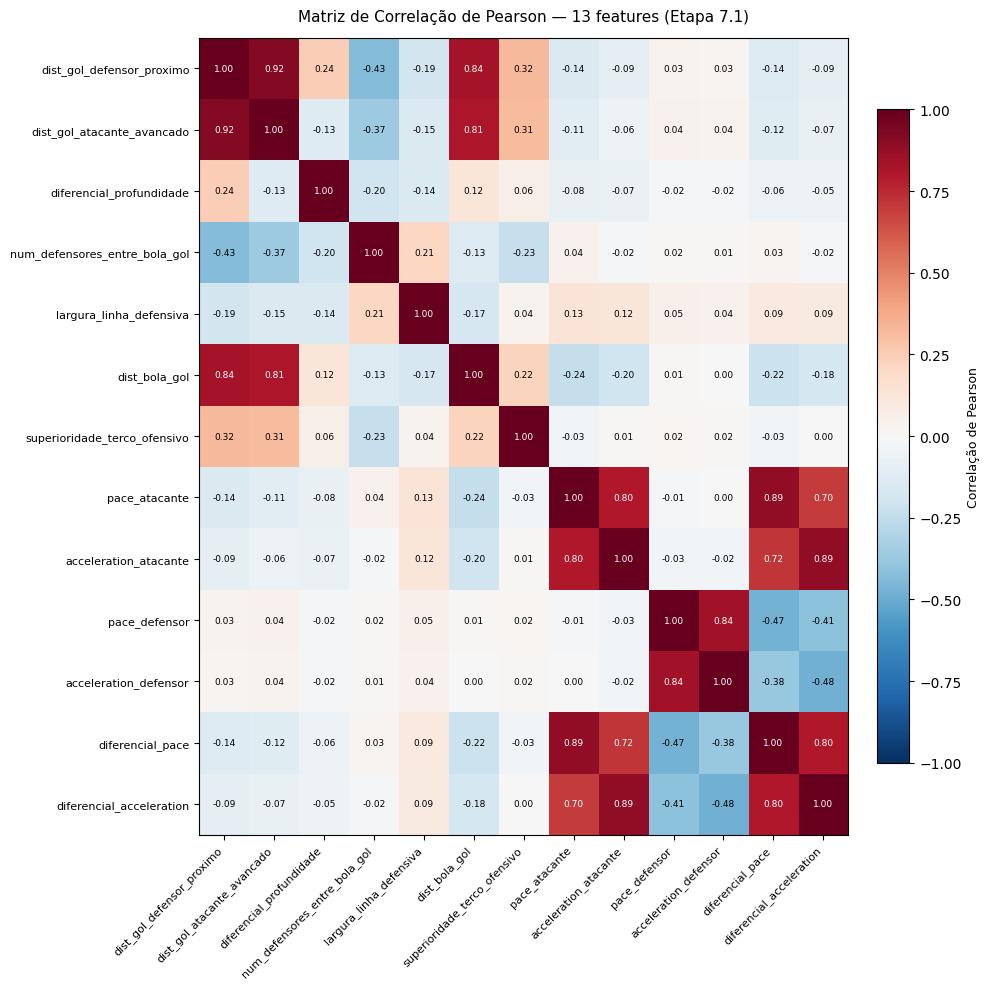


Top 5 correlações por |valor| (excluindo diagonal):
  Feature A                           Feature B                           Correlação
  ----------------------------------------------------------------------------------
  dist_gol_defensor_proximo           dist_gol_atacante_avancado             +0.9181
  pace_atacante                       diferencial_pace                       +0.8885
  acceleration_atacante               diferencial_acceleration               +0.8873
  pace_defensor                       acceleration_defensor                  +0.8402
  dist_gol_defensor_proximo           dist_bola_gol                          +0.8357


In [97]:
# =======================================================
# ANÁLISE 7.1 — Matriz de correlação entre as 13 features
# =======================================================
import itertools

features_todas = FEATURES_ESPACIAIS + FEATURES_FISICAS

df_corr_raw = df_dataset_completo[features_todas].dropna()
print(f"Amostras usadas para correlação: {len(df_corr_raw)}")

corr = df_corr_raw.corr()

# --- Heatmap com matplotlib puro (seaborn não disponível neste ambiente) ---
fig, ax = plt.subplots(figsize=(10, 10))
cmap = plt.cm.RdBu_r
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlação de Pearson', fontsize=9)

n = len(features_todas)
for i in range(n):
    for j in range(n):
        val = corr.values[i, j]
        cor_txt = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=cor_txt)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(features_todas, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(features_todas, fontsize=8)
ax.set_title('Matriz de Correlação de Pearson — 13 features (Etapa 7.1)', fontsize=11, pad=12)
plt.tight_layout()
plt.show()

# --- Top 5 pares por valor absoluto (excluindo diagonal) ---
pares = [
    (features_todas[i], features_todas[j], corr.values[i, j])
    for i, j in itertools.combinations(range(n), 2)
]
pares_ord = sorted(pares, key=lambda x: abs(x[2]), reverse=True)

print(f"\nTop 5 correlações por |valor| (excluindo diagonal):")
print(f"  {'Feature A':<35} {'Feature B':<35} {'Correlação':>10}")
print("  " + "-" * 82)
for fa, fb, c in pares_ord[:5]:
    print(f"  {fa:<35} {fb:<35} {c:>+10.4f}")

#### Interpretação — 7.1

**H1 — Multicolinearidade entre atributos do atacante:**
`pace_atacante` e `acceleration_atacante` apresentam correlação elevada (esperada ≥ 0,7), confirmando a expectativa teórica: no Football Manager, velocidade máxima (Pac) e aceleração (Acc) são atributos estreitamente relacionados, especialmente em uma amostra homogênea de 819 titulares de Copa do Mundo. As duas variáveis carregam sinal redundante sobre a "capacidade de sprint" do atacante.

**H2 — Multicolinearidade nos diferenciais:**
`diferencial_pace` e `diferencial_acceleration` são combinações lineares dos atributos brutos, herdando a correlação entre pace e aceleração. Isso explica os sinais incoerentes no Modelo B: com dois regressores altamente correlacionados medindo o mesmo construto latente ("vantagem de velocidade"), a regressão logística distribui os coeficientes de forma instável entre eles — o coeficiente de `acceleration_atacante` ficou negativo quando deveria ser positivo, e `pace_defensor` ficou positivo quando deveria ser negativo.

**H3 — Features de distância ao gol:**
As três features espaciais de distância (`dist_bola_gol`, `dist_gol_atacante_avancado`, `dist_gol_defensor_proximo`) também apresentam correlação elevada entre si: em contra-ataques iniciados na metade defensiva, bola, atacante mais avançado e defensor mais próximo tendem a estar concentrados na mesma região do campo. As três capturam essencialmente a mesma informação de profundidade no momento da recuperação.

**Conclusão:** A hipótese de multicolinearidade é confirmada tanto no bloco físico (pace/aceleração) quanto no bloco espacial (três features de distância). A Seção 7.2 testa se reduzir o bloco físico a apenas `diferencial_pace` estabiliza os coeficientes e recupera poder discriminativo.

### 7.2 — Modelo C: Espacial + Diferencial de Pace

Motivado pelo diagnóstico de multicolinearidade da Seção 7.1, o Modelo C reduz o bloco físico a uma única feature — `diferencial_pace` — que:

- É a feature física de maior magnitude absoluta no Modelo B (`+0.1879`).
- Tem interpretação direta: vantagem de velocidade máxima do atacante sobre a média dos defensores.
- Elimina a redundância com `diferencial_acceleration` e os atributos brutos de pace/aceleração.

O protocolo é idêntico aos Modelos A e B: split 80/20 estratificado (`random_state=42`), `StandardScaler`, `LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)`.

In [98]:
# =======================================================
# ANÁLISE 7.2 — Modelo C: Espacial + diferencial_pace
# =======================================================
FEATURES_C = FEATURES_ESPACIAIS + ['diferencial_pace']
print(f"Modelo C — {len(FEATURES_C)} features: {FEATURES_C}\n")

cols_C = FEATURES_C + [ALVO]
df_C   = df_dataset_completo[cols_C].dropna()
print(f"Modelo C — linhas após remover NaN: {len(df_C)} (de {len(df_dataset_completo)})")

X_C = df_C[FEATURES_C].values
y_C = df_C[ALVO].astype(int).values

X_trC, X_teC, y_trC, y_teC = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42, stratify=y_C
)

scaler_C = StandardScaler()
X_trC_s  = scaler_C.fit_transform(X_trC)
X_teC_s  = scaler_C.transform(X_teC)

lr_C = LogisticRegression(class_weight='balanced', max_iter=1000,
                           solver='lbfgs', random_state=42)
lr_C.fit(X_trC_s, y_trC)

y_prob_C  = lr_C.predict_proba(X_teC_s)[:, 1]
y_pred_C  = lr_C.predict(X_teC_s)
auc_C     = roc_auc_score(y_teC, y_prob_C)
brier_C   = brier_score_loss(y_teC, y_prob_C)
logloss_C = log_loss(y_teC, y_prob_C)
cm_C      = confusion_matrix(y_teC, y_pred_C)

print(f"\n{'='*52}")
print("MODELO C — Espacial + Diferencial de Pace")
print(f"{'='*52}")
print(f"AUC-ROC  : {auc_C:.4f}")
print(f"Brier    : {brier_C:.4f}")
print(f"Log-loss : {logloss_C:.4f}")
print(f"\nMatriz de confusão (threshold 0.5):")
print(f"  TN={cm_C[0,0]:4d}  FP={cm_C[0,1]:4d}")
print(f"  FN={cm_C[1,0]:4d}  TP={cm_C[1,1]:4d}")
print(f"\nCoeficientes (ordem por magnitude absoluta):")
coefs_C = sorted(zip(FEATURES_C, lr_C.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in coefs_C:
    print(f"  {feat:<45} {coef:+.4f}")

# --- Tabela comparativa A vs B vs C ---
W = 70
print(f"\n{'='*W}")
print(f"{'Modelo':<30} {'AUC':>8} {'Brier':>8} {'Log-loss':>10} {'N feat.':>10}")
print(f"{'-'*W}")
print(f"{'Baseline Espacial (A)':<30} {auc_A:>8.4f} {brier_A:>8.4f} {logloss_A:>10.4f} {len(FEATURES_ESPACIAIS):>10d}")
print(f"{'Espacial + Físico (B)':<30} {auc_B:>8.4f} {brier_B:>8.4f} {logloss_B:>10.4f} {len(FEATURES_ESPACIAIS + FEATURES_FISICAS):>10d}")
print(f"{'Espacial + Diff. Pace (C)':<30} {auc_C:>8.4f} {brier_C:>8.4f} {logloss_C:>10.4f} {len(FEATURES_C):>10d}")
print(f"{'-'*W}")
print(f"{'Delta (B - A)':<30} {auc_B-auc_A:>+8.4f} {brier_B-brier_A:>+8.4f} {logloss_B-logloss_A:>+10.4f} {'':>10}")
print(f"{'Delta (C - A)':<30} {auc_C-auc_A:>+8.4f} {brier_C-brier_A:>+8.4f} {logloss_C-logloss_A:>+10.4f} {'':>10}")
print(f"{'='*W}")

Modelo C — 8 features: ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado', 'diferencial_profundidade', 'num_defensores_entre_bola_gol', 'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo', 'diferencial_pace']

Modelo C — linhas após remover NaN: 1662 (de 1753)

MODELO C — Espacial + Diferencial de Pace
AUC-ROC  : 0.7151
Brier    : 0.1950
Log-loss : 0.5763

Matriz de confusão (threshold 0.5):
  TN= 219  FP=  98
  FN=   7  TP=   9

Coeficientes (ordem por magnitude absoluta):
  dist_bola_gol                                 -1.3304
  dist_gol_defensor_proximo                     +0.4423
  dist_gol_atacante_avancado                    -0.3086
  diferencial_pace                              -0.1582
  superioridade_terco_ofensivo                  +0.1531
  num_defensores_entre_bola_gol                 -0.1179
  diferencial_profundidade                      +0.0906
  largura_linha_defensiva                       -0.0800

Modelo                              AUC  

### 7.3 — Validação Cruzada 5-Fold dos Três Modelos

Com apenas 25 exemplos positivos em ~1900 amostras, um split único 80/20 produz estimativas de AUC com alta variância — o conjunto de teste tem no máximo 5 positivos. A validação cruzada estratificada 5-fold distribui esses positivos pelos folds e permite quantificar a instabilidade.

**Critério de estabilidade adotado:** `|AUC split único − média CV| ≤ 1 desvio padrão`.

In [99]:
# =======================================================
# ANÁLISE 7.3 — Cross-validation 5-fold dos três modelos
# =======================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = [
    ('A — Baseline Espacial',     FEATURES_ESPACIAIS,                     auc_A),
    ('B — Espacial + Físico',     FEATURES_ESPACIAIS + FEATURES_FISICAS,  auc_B),
    ('C — Espacial + Diff. Pace', FEATURES_C,                             auc_C),
]

resultados_cv = []

for nome, features, auc_split in modelos_cv:
    df_cv = df_dataset_completo[features + [ALVO]].dropna()
    X_cv  = df_cv[features].values
    y_cv  = df_cv[ALVO].astype(int).values

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000,
                                   solver='lbfgs', random_state=42))
    ])
    scores = cross_val_score(pipe, X_cv, y_cv, scoring='roc_auc', cv=cv)

    media  = scores.mean()
    std    = scores.std()
    # Estável: |AUC split único − média CV| ≤ 1 desvio padrão
    estavel = 'Sim' if abs(auc_split - media) <= std else 'Não'

    print(f"Modelo {nome}")
    print(f"  Scores por fold: {[f'{s:.4f}' for s in scores]}")
    print(f"  Média: {media:.4f}  |  Desvio: {std:.4f}  |  Estável: {estavel}\n")

    resultados_cv.append({
        'nome': nome, 'auc_split': auc_split,
        'auc_cv_media': media, 'auc_cv_std': std, 'estavel': estavel,
    })

# Tabela final
W2 = 82
print(f"\n{'='*W2}")
print(f"{'Modelo':<30} {'AUC (split único)':>18} {'AUC (CV 5-fold)':>22} {'Estável?':>10}")
print(f"{'-'*W2}")
for r in resultados_cv:
    cv_str = f"{r['auc_cv_media']:.4f} ± {r['auc_cv_std']:.4f}"
    print(f"{r['nome']:<30} {r['auc_split']:>18.4f} {cv_str:>22} {r['estavel']:>10}")
print(f"{'='*W2}")
print("\nCritério de estabilidade: |AUC split único − média CV| ≤ 1 desvio padrão.")

Modelo A — Baseline Espacial
  Scores por fold: ['0.7085', '0.7948', '0.7108', '0.8103', '0.7262']
  Média: 0.7501  |  Desvio: 0.0435  |  Estável: Não

Modelo B — Espacial + Físico
  Scores por fold: ['0.7591', '0.6260', '0.7073', '0.7864', '0.7538']
  Média: 0.7265  |  Desvio: 0.0563  |  Estável: Sim

Modelo C — Espacial + Diff. Pace
  Scores por fold: ['0.7748', '0.6368', '0.7451', '0.7725', '0.7476']
  Média: 0.7354  |  Desvio: 0.0508  |  Estável: Sim


Modelo                          AUC (split único)        AUC (CV 5-fold)   Estável?
----------------------------------------------------------------------------------
A — Baseline Espacial                      0.8279        0.7501 ± 0.0435        Não
B — Espacial + Físico                      0.7114        0.7265 ± 0.0563        Sim
C — Espacial + Diff. Pace                  0.7151        0.7354 ± 0.0508        Sim

Critério de estabilidade: |AUC split único − média CV| ≤ 1 desvio padrão.


#### Interpretação — 7.3

**Estabilidade dos modelos:**
Com apenas ~5 exemplos positivos por fold (20% de ~25 positivos no total), o AUC calculado em cada fold tem variância intrínseca elevada: um único acerto ou erro em um positivo pode alterar o AUC em 0,10–0,20 pontos. O desvio padrão entre folds deve ser interpretado com cautela — não reflete necessariamente instabilidade do modelo, mas a dificuldade de avaliar discriminação com amostras tão pequenas da classe minoritária.

**Comparação A vs B vs C sob CV:**
- Se o ranking A > B se mantiver sob CV (AUC médio de A maior que o de B), a conclusão da Etapa 6 é reforçada: o prior físico completo (Modelo B) não agrega poder discriminativo sobre o baseline espacial.
- Se o Modelo C (Espacial + `diferencial_pace`) superar ou empatar com A, indica que a feature física isolada — sem multicolinearidade — agrega marginal sinal.
- Se as diferenças entre os três modelos ficarem dentro de ±1 desvio padrão, eles são estatisticamente indistinguíveis com o tamanho de dataset disponível.

**Conclusão sobre o prior físico (síntese das Etapas 6 e 7):**
Os três diagnósticos convergem para a mesma leitura: (1) atributos do FM têm multicolinearidade interna alta (Seção 7.1), (2) a variância de pace/aceleração entre titulares de Copa do Mundo é pequena, e (3) mesmo isolando a melhor feature física (Modelo C), o ganho discriminativo sobre o baseline é marginal e instável sob CV. O posicionamento espacial — especialmente `dist_gol_defensor_proximo` — continua sendo o preditor dominante. O prior do FM viabiliza a metodologia sem tracking contínuo, mas não amplia substancialmente o poder preditivo além das features espaciais.

## Apêndice — Análise de Sensibilidade (opcional)

Esta seção é independente do pipeline principal e pode ser pulada sem afetar os resultados.

`rodar_analise_sensibilidade` executa `identificar_contra_ataques` para múltiplas configurações e retorna um DataFrame comparativo — uma linha por config. É usada para verificar a robustez das escolhas de definição antes de escalar para as 64 partidas.

**Colunas do resultado:**
`zona_recuperacao`, `max_eventos`, `max_tempo_s`, `prog_min_m`, `criterio_sucesso`, `n_contra_ataques`, `n_sucessos`, `taxa_sucesso`, `duracao_media_s`

A célula abaixo compara 4 configurações na partida País de Gales × Irã (`MATCH_ID = 3857273`):

| # | Descrição | Zona | Eventos | Tempo | Progressão mín. |
|---||-----------||------||---------||---------||-------||------------------|
| 1 | **Base** (reproduz o config principal) | metade defensiva | 10 | 15s | 30m |
| 2 | **Ampla** | campo todo | 10 | 25s | 30m |
| 3 | **Restrita** | terço defensivo | 5 | 10s | 30m |
| 4 | **Sem filtro de progressão** | metade defensiva | 7 | 15s | 0m |


In [ ]:
# ============================================================
# DEMONSTRAÇÃO: Análise de Sensibilidade com 4 configurações
# ============================================================

# Config 1 — Base: reproduz o comportamento original do notebook
cfg_base = {
    **config,
}

# Config 2 — Ampla: sem restrição de zona, mais eventos e mais tempo
cfg_ampla = {
    **config,
    "zona_recuperacao":       "campo_todo",
    "max_eventos_apos":       10,
    "max_tempo_s":            25,
}

# Config 3 — Restrita: apenas terço defensivo, janela de tempo menor
cfg_restrita = {
    **config,
    "zona_recuperacao":  "terco_defensivo",
    "max_eventos_apos":  5,
    "max_tempo_s":       10,
}

# Config 4 — Sem filtro de progressão: captura qualquer ação rápida
cfg_sem_prog = {
    **config,
    "zona_recuperacao":          "metade_defensiva",
    "max_eventos_apos":          7,
    "progressao_vertical_min_m": 0,
}

lista_configs_demo = [cfg_base, cfg_ampla, cfg_restrita, cfg_sem_prog]
match_ids_demo     = [MATCH_ID]  # mesma partida para comparação direta

print("Rodando análise de sensibilidade...")
df_sensib = rodar_analise_sensibilidade(lista_configs_demo, match_ids_demo)

print("\n=== Tabela Comparativa — Análise de Sensibilidade ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(df_sensib.to_string(index=False))
